# 07 — CGM Daily Means & Comorbidity Cluster Analysis

**Purpose**: Aggregate real CGM daily mean glucose values, analyze their spread across comorbidity clusters, and engineer a model-ready feature set for the upcoming modeling phase.

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.

**Builds on**: Notebooks 05 & 06 — reuses their `item_key` parsing pattern and feature engineering logic. Self-contained: re-derives all features from source data.

**Outputs**:
- `data/processed/comorbidity_clusters.csv` — cluster assignments for all participants
- `data/processed/cgm_aggregated.csv` — per-person CGM + cluster + study group
- `data/processed/features_with_cluster.csv` — model-ready feature table (cluster included)
- `data/processed/features_without_cluster.csv` — model-ready feature table (no cluster)

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. CGM Data Aggregation
4. Comorbidity Cluster Re-derivation
5. Spread Analysis: CGM vs Comorbidity Clusters
6. Feature Engineering for Modeling
7. Completeness Audit & Summary

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, json, getpass, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_ID       = '00b62456-0b93-4975-a992-42ba6a50ed5c'
CONTAINER_NAME = 'aireadi-raw'

STUDY_GROUP_MAP = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP     = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}

print('Environment ready.')

Environment ready.


In [3]:
# ── 2. Azure Connection & Data Load ──────────────────────────────
from azure.storage.blob import BlobServiceClient

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    print('Connected.')
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('Credentials loaded from local cofnig.')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV/TSV from Azure Blob directly into a DataFrame."""
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

# Load participants
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
print(f'Participants: {len(participants):,} rows  cols: {participants.columns.tolist()}')

# Load observation table (~108 MB)
print('Loading observation.csv (~108 MB) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'Observations: {len(obs_raw):,} rows x {obs_raw.shape[1]} cols')

Paste your Azure CONNECTION_STRING when prompted:
Connected.
Participants: 2,280 rows  cols: ['person_id', 'clinical_site', 'study_group', 'age', 'study_visit_date', 'recommended_split', 'cardiac_ecg', 'clinical_data', 'environment', 'retinal_flio', 'retinal_oct', 'retinal_octa', 'retinal_photography', 'wearable_activity_monitor', 'wearable_blood_glucose']
Loading observation.csv (~108 MB) ...
Observations: 707,126 rows x 22 cols


In [26]:
# ── 2b. Parse item_key and build obs_df (mirrors notebooks 05 & 06) ───────

obs_df = obs_raw.copy()

# Parse item key from observation_source_value (e.g. "ces1, CES-D Item 1" -> "ces1")
obs_df['item_key'] = (
    obs_df['observation_source_value']
    .astype(str)
    .str.split(',', n=1)
    .str[0]
    .str.strip()
    .str.lower()
)

# Clean numeric values; recode sentinel 99 -> NaN
obs_df['value_clean'] = pd.to_numeric(obs_df['value_as_number'], errors='coerce')
obs_df.loc[obs_df['value_clean'] == 99, 'value_clean'] = np.nan

print(f'Item keys in obs_df: {obs_df["item_key"].nunique():,} unique')

# Study group map
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
print(f'Study group column: {sg_col}')

STUDY_GROUP_STR_MAP = {
    # short / legacy variants
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    # actual values in aireadi participants table
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}

if sg_col:
    participants['study_group_code']  = (participants[sg_col].str.lower()
                                         .str.strip().map(STUDY_GROUP_STR_MAP))
    participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
    group_map = participants.set_index('person_id')['study_group_label'].to_dict()
    print(participants['study_group_label'].value_counts().to_string())
else:
    group_map = {}
    print('WARNING: study group column not found')

# Helper: pivot item keys to wide format (person_id x item)
def pivot_instrument(df, item_keys, value_col='value_clean'):
    present_keys = [k for k in item_keys if k in df['item_key'].values]
    if not present_keys:
        return pd.DataFrame()
    long = df[df['item_key'].isin(present_keys)][['person_id', 'item_key', value_col]]
    wide = long.pivot_table(index='person_id', columns='item_key',
                             values=value_col, aggfunc='mean')
    wide.columns.name = None
    return wide

Item keys in obs_df: 361 unique
Study group column: study_group
study_group_label
Healthy     776
Oral Med    686
Pre-DM      560
Insulin     258


In [27]:
# ── 3. CGM Data Aggregation ───────────────────────────────────────
# average_glucose_level_mg_dl is computed from the actual Dexcom G6 readings
# -- the real CGM mean, not a proxy. Loaded from Azure like all other data.

print('Loading CGM manifest from Azure ...')
cgm = load_blob_csv(f'{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv', sep='\t')

cgm = cgm.rename(columns={
    'average_glucose_level_mg_dl':           'mean_glucose',
    'glucose_sensor_sampling_duration_days':  'cgm_days',
    'glucose_level_record_count':             'cgm_record_count',
})

cgm['readings_per_day'] = cgm['cgm_record_count'] / cgm['cgm_days'].replace(0, float('nan'))

print(f'CGM manifest: {len(cgm):,} participants  ({len(cgm)/2280*100:.1f}% of cohort)')
print(cgm[['mean_glucose', 'cgm_days', 'readings_per_day']].describe().round(2))


Loading CGM manifest from Azure ...
CGM manifest: 2,245 participants  (98.5% of cohort)
       mean_glucose  cgm_days  readings_per_day
count      2245.000  2245.000          2245.000
mean        135.290    10.700           256.800
std          34.720     1.080            16.700
min          67.560     2.000            14.000
25%         113.450    11.000           257.730
50%         124.950    11.000           259.550
75%         145.460    11.000           259.640
max         310.920    15.000           287.250


### Note: Within-person daily variability

Raw Dexcom G6 JSON files (one per participant) contain 5-minute readings for computing true day-to-day variability. They live in Azure at `{STUDY_ID}/dataset/wearable_blood_glucose/continuous_glucose_monitoring/dexcom_g6/{person_id}/{person_id}_DEX.json`. Pulling all 2,245 files in-notebook would be slow; a future notebook can pull a sample if needed. For now, `average_glucose_level_mg_dl` from the manifest serves as the primary modeling target.

In [28]:
# ── 4. Comorbidity Cluster Re-derivation ─────────────────────────────
# Uses mhoccur_* item keys -- exact same approach as notebooks 05 & 06.

mh_keys        = [k for k in obs_df['item_key'].unique() if k.startswith('mhoccur')]
mh_binary_keys = [k for k in mh_keys if 'fallot' not in k]  # exclude fall count (continuous)
print(f'Comorbidity binary items: {len(mh_binary_keys)}  e.g. {mh_binary_keys[:5]}')

mh_wide = pivot_instrument(obs_df, mh_binary_keys)
mh_wide = mh_wide.clip(upper=1)  # binarize

# Reindex to full cohort; absent = 0 comorbidities
all_pids = participants['person_id'].unique()
mh_wide  = mh_wide.reindex(all_pids, fill_value=0)

mh_wide['study_group']      = mh_wide.index.map(group_map)
mh_wide['comorbidity_index'] = mh_wide[mh_binary_keys].sum(axis=1)

# K-means k=2 (matching notebook 06)
mh_binary = mh_wide[mh_binary_keys].fillna(0).values
km = KMeans(n_clusters=2, random_state=42, n_init=20)
mh_wide['comorbidity_cluster'] = km.fit_predict(mh_binary)

sil = silhouette_score(mh_binary, mh_wide['comorbidity_cluster'])
print(f'Silhouette score: {sil:.4f}  (nb06 baseline ~0.14)')
print(mh_wide['comorbidity_cluster'].value_counts().rename(CLUSTER_MAP))

for c in [0, 1]:
    mask = mh_wide['comorbidity_cluster'] == c
    top  = mh_wide.loc[mask, mh_binary_keys].mean().nlargest(5)
    print(f'\nCluster {c} ({CLUSTER_MAP[c]}) top conditions:')
    print(top.round(3).to_string())

# ── Mount Google Drive and set persistent out_dir ───────────────────────────
import shutil
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Output dir:', out_dir)

clusters_out = (mh_wide[['comorbidity_cluster', 'comorbidity_index']]
                .reset_index()
                .rename(columns={'index': 'person_id'}))
if clusters_out.columns[0] != 'person_id':
    clusters_out = clusters_out.rename(columns={clusters_out.columns[0]: 'person_id'})
clusters_out.to_csv(out_dir / 'comorbidity_clusters.csv', index=False)
print(f'\nSaved comorbidity_clusters.csv ({len(clusters_out):,} rows)')

Comorbidity binary items: 29  e.g. ['mhoccur_mi', 'mhoccur_cvdot', 'mhoccur_strk', 'mhoccur_clsh', 'mhoccur_hbp']
Silhouette score: 0.1417  (nb06 baseline ~0.14)
comorbidity_cluster
Musculoskeletal-Inflammatory    1350
Cardiometabolic                  930
Name: count, dtype: int64

Cluster 0 (Cardiometabolic) top conditions:
mhoccur_ra     0.772
mhoccur_hbp    0.723
mhoccur_clsh   0.718
mhoccur_obs    0.566
mhoccur_crt    0.562

Cluster 1 (Musculoskeletal-Inflammatory) top conditions:
mhoccur_clsh   0.367
mhoccur_hbp    0.359
mhoccur_obs    0.261
mhoccur_ded    0.194
mhoccur_ra     0.173
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output dir: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs

Saved comorbidity_clusters.csv (2,280 rows)


In [29]:
# ── 4b. Merge CGM + clusters + study group ────────────────────────────

participants_slim = participants[['person_id', 'study_group_code', 'study_group_label']].copy()

cgm_merged = (
    cgm[['person_id', 'mean_glucose', 'cgm_days', 'cgm_record_count', 'readings_per_day']]
    .merge(clusters_out[['person_id', 'comorbidity_cluster', 'comorbidity_index']],
           on='person_id', how='left')
    .merge(participants_slim, on='person_id', how='left')
)

print(f'Merged CGM dataset: {len(cgm_merged):,} rows')
print(f'  Missing cluster:     {cgm_merged["comorbidity_cluster"].isna().sum()}')
print(f'  Missing study group: {cgm_merged["study_group_code"].isna().sum()}')
print()
print(cgm_merged.groupby('comorbidity_cluster')['mean_glucose']
      .agg(['count','mean','std','median']).round(2)
      .rename(index=CLUSTER_MAP))

cgm_merged.to_csv(out_dir / 'cgm_aggregated.csv', index=False)
print(f'\nSaved cgm_aggregated.csv ({len(cgm_merged):,} rows)')

Merged CGM dataset: 2,245 rows
  Missing cluster:     0
  Missing study group: 0

                              count    mean    std  median
comorbidity_cluster                                       
Cardiometabolic                 919 139.110 35.900 129.040
Musculoskeletal-Inflammatory   1326 132.650 33.650 123.440

Saved cgm_aggregated.csv (2,245 rows)


## 5. Spread Analysis: CGM vs Comorbidity Clusters

Two lenses:
- **Between-cluster**: distribution of mean glucose across the two clusters
- **Within-person**: day-to-day variability (from raw JSON sample subset)

study_group_label values in data: ['Healthy', 'Insulin', 'Oral Med', 'Pre-DM']


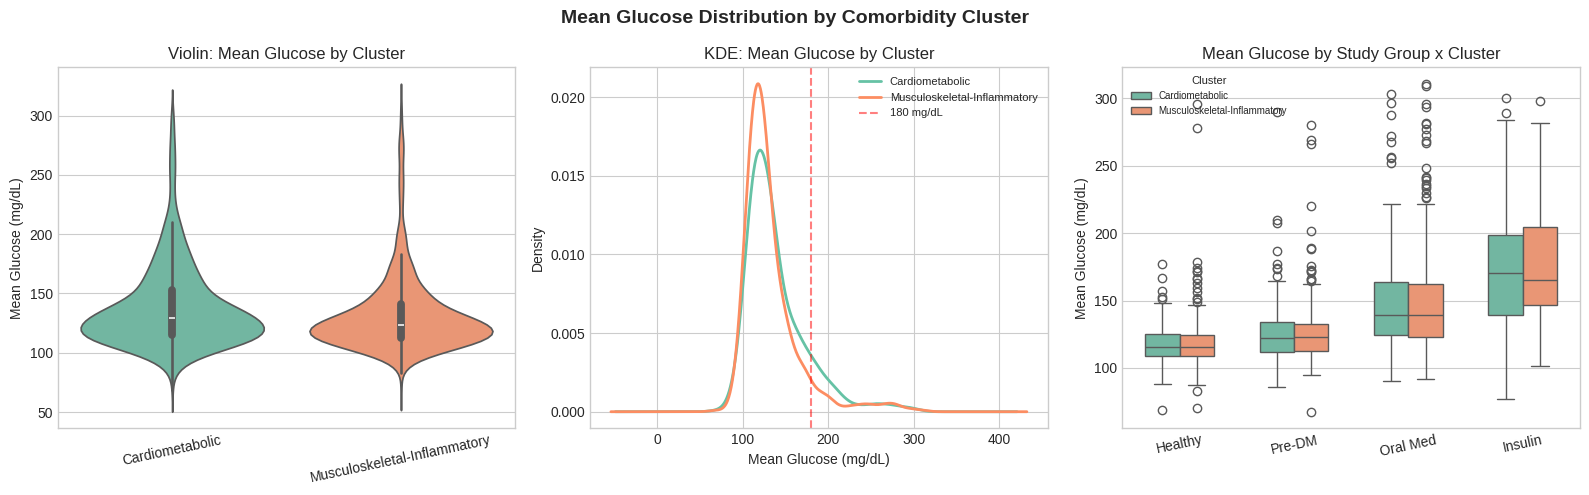

=== Between-cluster glucose comparison ===
Cluster 0 (Cardiometabolic):        mean=139.1, SD=35.9, N=919
Cluster 1 (Musculoskeletal-Inflam): mean=132.7, SD=33.6, N=1,326
Mann-Whitney U p=0.0000   Cohens d=0.186 (small effect)


In [30]:
# ── 5a. Between-cluster glucose distribution ────────────────────────────

df_plot = cgm_merged.dropna(subset=['comorbidity_cluster', 'mean_glucose']).copy()
df_plot['cluster_label'] = df_plot['comorbidity_cluster'].map(CLUSTER_MAP)

# Stable color map keyed by label name so violin, KDE, and boxplot are consistent
_set2 = sns.color_palette('Set2')
label_palette = {
    'Cardiometabolic':              _set2[0],
    'Musculoskeletal-Inflammatory': _set2[1],
}
label_order = list(label_palette.keys())

# Verify study_group_label values match the expected order
print('study_group_label values in data:', sorted(df_plot['study_group_label'].dropna().unique()))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Glucose Distribution by Comorbidity Cluster', fontsize=14, fontweight='bold')

sns.violinplot(data=df_plot, x='cluster_label', y='mean_glucose',
               order=label_order,
               palette=label_palette, inner='box', ax=axes[0])
axes[0].set_title('Violin: Mean Glucose by Cluster')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')
axes[0].tick_params(axis='x', rotation=12)

for c, label in CLUSTER_MAP.items():
    subset = df_plot[df_plot['comorbidity_cluster'] == c]['mean_glucose'].dropna()
    subset.plot.kde(ax=axes[1], label=label, linewidth=2, color=label_palette[label])
axes[1].axvline(180, color='red', linestyle='--', alpha=0.5, label='180 mg/dL')
axes[1].set_title('KDE: Mean Glucose by Cluster')
axes[1].set_xlabel('Mean Glucose (mg/dL)')
axes[1].legend(fontsize=8)

order = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
sns.boxplot(data=df_plot, x='study_group_label', y='mean_glucose',
            hue='cluster_label', order=order, hue_order=label_order,
            palette=label_palette, width=0.6, ax=axes[2])
axes[2].set_title('Mean Glucose by Study Group x Cluster')
axes[2].set_xlabel('')
axes[2].set_ylabel('Mean Glucose (mg/dL)')
axes[2].legend(title='Cluster', fontsize=7, title_fontsize=8)
axes[2].tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.show()

c0 = df_plot[df_plot['comorbidity_cluster'] == 0]['mean_glucose'].dropna()
c1 = df_plot[df_plot['comorbidity_cluster'] == 1]['mean_glucose'].dropna()

stat, p = stats.mannwhitneyu(c0, c1, alternative='two-sided')
cohens_d = (c0.mean() - c1.mean()) / np.sqrt((c0.std()**2 + c1.std()**2) / 2)
effect = 'small' if abs(cohens_d) < 0.5 else ('medium' if abs(cohens_d) < 0.8 else 'large')

print('=== Between-cluster glucose comparison ===')
print(f'Cluster 0 (Cardiometabolic):        mean={c0.mean():.1f}, SD={c0.std():.1f}, N={len(c0):,}')
print(f'Cluster 1 (Musculoskeletal-Inflam): mean={c1.mean():.1f}, SD={c1.std():.1f}, N={len(c1):,}')
print(f'Mann-Whitney U p={p:.4f}   Cohens d={cohens_d:.3f} ({effect} effect)')

In [31]:
# ── 5b. Distribution shape by cluster ──────────────────────────────────

print('=== Distribution shape by cluster ===')
for c, label in CLUSTER_MAP.items():
    vals = df_plot[df_plot['comorbidity_cluster'] == c]['mean_glucose'].dropna()
    skew = stats.skew(vals)
    kurt = stats.kurtosis(vals)
    pct_high = (vals > 180).mean() * 100
    print(f'\n{label} (Cluster {c}):')
    print(f'  Skewness:      {skew:.3f}  ({"right-skewed" if skew>0.5 else "left-skewed" if skew<-0.5 else "approx. symmetric"})')
    print(f'  Kurtosis:      {kurt:.3f}')
    print(f'  % > 180 mg/dL: {pct_high:.1f}%')
    print(f'  Median:        {vals.median():.1f} mg/dL')
    print(f'  IQR:           {vals.quantile(0.25):.1f} - {vals.quantile(0.75):.1f} mg/dL')

=== Distribution shape by cluster ===

Cardiometabolic (Cluster 0):
  Skewness:      1.708  (right-skewed)
  Kurtosis:      3.620
  % > 180 mg/dL: 11.8%
  Median:        129.0 mg/dL
  IQR:           115.0 - 153.3 mg/dL

Musculoskeletal-Inflammatory (Cluster 1):
  Skewness:      2.365  (right-skewed)
  Kurtosis:      6.925
  % > 180 mg/dL: 7.2%
  Median:        123.4 mg/dL
  IQR:           112.8 - 140.9 mg/dL


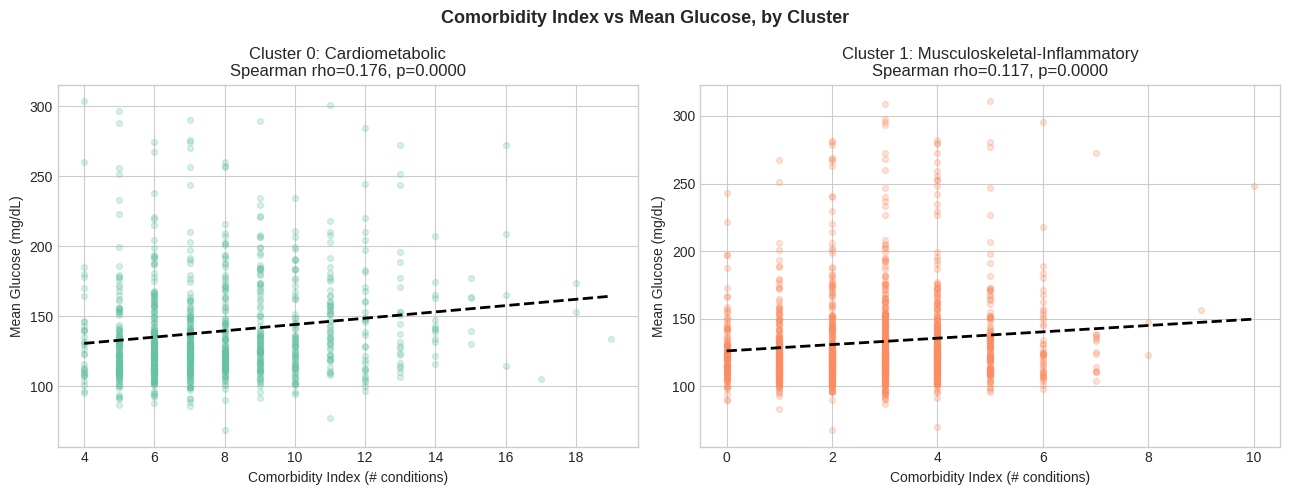

  Cluster 0 (Cardiometabolic): rho=0.176, p=0.0000, N=919
  Cluster 1 (Musculoskeletal-Inflammatory): rho=0.117, p=0.0000, N=1,326


In [32]:
# ── 5c. Comorbidity index gradient within clusters ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comorbidity Index vs Mean Glucose, by Cluster', fontsize=13, fontweight='bold')

for i, (c, label) in enumerate(CLUSTER_MAP.items()):
    ax  = axes[i]
    sub = df_plot[df_plot['comorbidity_cluster'] == c].dropna(
        subset=['comorbidity_index', 'mean_glucose'])
    col = label_palette[label]

    ax.scatter(sub['comorbidity_index'], sub['mean_glucose'], alpha=0.25, s=18, color=col)

    slope, intercept, *_ = stats.linregress(sub['comorbidity_index'], sub['mean_glucose'])
    x_range = np.linspace(sub['comorbidity_index'].min(), sub['comorbidity_index'].max(), 100)
    ax.plot(x_range, slope*x_range + intercept, color='black', linewidth=2, linestyle='--')

    rho, p_sp = stats.spearmanr(sub['comorbidity_index'], sub['mean_glucose'])
    ax.set_title(f'Cluster {c}: {label}\nSpearman rho={rho:.3f}, p={p_sp:.4f}')
    ax.set_xlabel('Comorbidity Index (# conditions)')
    ax.set_ylabel('Mean Glucose (mg/dL)')

plt.tight_layout()
plt.show()

for c, label in CLUSTER_MAP.items():
    sub = df_plot[df_plot['comorbidity_cluster'] == c].dropna(
        subset=['comorbidity_index', 'mean_glucose'])
    rho, p_sp = stats.spearmanr(sub['comorbidity_index'], sub['mean_glucose'])
    print(f'  Cluster {c} ({label}): rho={rho:.3f}, p={p_sp:.4f}, N={len(sub):,}')

### Note: Within-person variability (skipped in Colab version)

Day-to-day glucose SD and CV require raw per-reading JSON files, which are not loaded in this notebook. See the note in Section 3 above for the Azure path structure to extend this analysis.

## 6. Feature Engineering for Modeling

Re-derives all features using the same `item_key` pattern as notebooks 05 & 06.
Exports two versions: with and without `comorbidity_cluster` as a predictor.

In [33]:
# ── 6a. CES-D-10 (depression) ──────────────────────────────────────────

cesd_keys = [f'ces{i}' for i in range(1, 11)] + ['cestl']
cesd_wide = pivot_instrument(obs_df, cesd_keys)
print(f'CES-D-10: {len(cesd_wide):,} participants')

if 'cestl' in cesd_wide.columns:
    cesd_out = cesd_wide[['cestl']].rename(columns={'cestl': 'cesd_total'})
else:
    item_cols = [k for k in cesd_keys if k != 'cestl' and k in cesd_wide.columns]
    cesd_out  = cesd_wide[item_cols].sum(axis=1, min_count=1).to_frame('cesd_total')

print(f'  Mean={cesd_out["cesd_total"].mean():.2f}  '
      f'coverage={cesd_out["cesd_total"].notna().mean()*100:.1f}%')

CES-D-10: 2,279 participants
  Mean=5.85  coverage=99.9%


In [34]:
# ── 6b. PAID-5 (diabetes distress) ─────────────────────────────────────

paid_keys = ['paid_scrd', 'paid_dpr', 'paid_wr', 'paid_eng', 'paid_cml', 'paidscore']
paid_wide = pivot_instrument(obs_df, paid_keys)
print(f'PAID-5: {len(paid_wide):,} participants')

if 'paidscore' in paid_wide.columns:
    paid_out = paid_wide[['paidscore']].rename(columns={'paidscore': 'paid_total'})
else:
    item_cols = [k for k in paid_keys if k != 'paidscore' and k in paid_wide.columns]
    paid_out  = paid_wide[item_cols].sum(axis=1, min_count=1).to_frame('paid_total')

print(f'  Mean={paid_out["paid_total"].mean():.2f}  '
      f'coverage={paid_out["paid_total"].notna().mean()*100:.1f}%')

PAID-5: 2,229 participants
  Mean=4.00  coverage=100.0%


In [35]:
# ── 6c. DML adherence gaps ──────────────────────────────────────────

DML_DOMAINS = {
    'physical_activity': ['dmlact', 'dmlvex', 'dmlhex'],
    'diet_adherence':   ['dmlsugar', 'dmlgrain', 'dmlpor', 'dmlfrveg'],
    'education':        ['dmledu'],
    'foot_care':        ['dmlfeet'],
    'medication_mgmt':  ['dmlmd'],
}

dml_all_keys = [k for keys in DML_DOMAINS.values() for k in keys]
dml_wide     = pivot_instrument(obs_df, dml_all_keys)
print(f'DML data: {len(dml_wide):,} participants')

dml_out = pd.DataFrame(index=dml_wide.index)
for domain, keys in DML_DOMAINS.items():
    present = [k for k in keys if k in dml_wide.columns]
    if present:
        # DML items are 3-level ordinal {0, 5, 10}; mean gives domain score 0-10
        dml_out[f'dml_gap_{domain}'] = 10 - dml_wide[present].mean(axis=1)

gap_cols = [c for c in dml_out.columns]
dml_out['dml_gap_composite'] = dml_out[gap_cols].mean(axis=1)
print(dml_out.describe().round(2))

DML data: 2,280 participants
       dml_gap_physical_activity  dml_gap_diet_adherence  dml_gap_education  \
count                   2280.000                2280.000           2280.000   
mean                       2.110                   0.980              3.960   
std                       25.900                  28.420             56.190   
min                     -509.670                -574.000           -767.000   
25%                        1.670                   2.500              5.000   
50%                        3.330                   3.750             10.000   
75%                        6.670                   5.000             10.000   
max                       10.000                  10.000             10.000   

       dml_gap_foot_care  dml_gap_medication_mgmt  dml_gap_composite  
count           2280.000                 2280.000           2280.000  
mean               1.780                  -38.120             -5.860  
std               39.750                  169.

In [36]:
# ── 6d. SDOH subscales ─────────────────────────────────────────────
# Mirror notebook 06: pxrd* for discrimination/access/food-housing,
# pxne* for neighborhood safety.

pxrd_keys = sorted([k for k in obs_df['item_key'].unique()
                    if k.startswith('pxrd')
                    and not any(k.endswith(s) for s in ['mpdat','mpts','startts','dat'])])
pxne_keys = sorted([k for k in obs_df['item_key'].unique()
                    if k.startswith('pxne')
                    and not any(k.endswith(s) for s in ['mpdat','mpts','startts','dat'])])

print(f'pxrd* keys: {len(pxrd_keys)}   pxne* keys: {len(pxne_keys)}')

pxrd_wide = pivot_instrument(obs_df, pxrd_keys)
pxne_wide = pivot_instrument(obs_df, pxne_keys)

sdoh_out = pd.DataFrame(index=participants['person_id'].unique())
sdoh_out.index.name = 'person_id'

# Split pxrd keys into subscale groups (following notebook 06 grouping)
d_cols = [k for k in pxrd_keys if k in pxrd_wide.columns][:14]   # discrimination
h_cols = [k for k in pxrd_keys if k in pxrd_wide.columns][14:28]  # healthcare access
f_cols = [k for k in pxrd_keys if k in pxrd_wide.columns][28:]    # food/housing
pn_cols = [k for k in pxne_keys if k in pxne_wide.columns]        # neighborhood safety

if d_cols:  sdoh_out['discrimination_score']      = pxrd_wide[d_cols].mean(axis=1)
if h_cols:  sdoh_out['healthcare_access_barriers'] = (pxrd_wide[h_cols] >= 3).sum(axis=1)
if f_cols:  sdoh_out['food_housing_insecurity']    = (pxrd_wide[f_cols] >= 3).any(axis=1).astype(float)
if pn_cols: sdoh_out['neighborhood_safety_score']  = pxne_wide[pn_cols].mean(axis=1)

print(sdoh_out.describe().round(3))

pxrd* keys: 53   pxne* keys: 17
       discrimination_score  healthcare_access_barriers  \
count              2280.000                    2280.000   
mean                 14.728                       2.267   
std                  83.204                       3.387   
min                   1.000                       0.000   
25%                   1.000                       0.000   
50%                   1.538                       0.000   
75%                   2.231                       3.000   
max                 777.000                      14.000   

       food_housing_insecurity  neighborhood_safety_score  
count                 2280.000                   2154.000  
mean                     0.609                     19.652  
std                      0.488                     46.395  
min                      0.000                      0.941  
25%                      0.000                      2.235  
50%                      1.000                      2.765  
75%             

In [37]:
# ── 6e. Substance use & OTC burden ───────────────────────────────────

su_keys = [k for k in obs_df['item_key'].unique()
           if k.startswith('su') and not k.endswith(('mpdat','mpts','startts'))]
otc_keys = ['cm_act', 'cm_ant', 'cm_asp', 'cm_dcg', 'cm_ibp', 'cm_slp']

su_wide  = pivot_instrument(obs_df, su_keys)
otc_wide = pivot_instrument(obs_df, otc_keys)

su_out = (su_wide > 0).sum(axis=1).to_frame('substance_exposure_count')

otc_present = [k for k in otc_keys if k in otc_wide.columns]
otc_out     = otc_wide[otc_present].sum(axis=1, min_count=1).to_frame('otc_burden_count')

print(f'Substance use: {len(su_out):,} participants, mean={su_out["substance_exposure_count"].mean():.2f}')
print(f'OTC burden:    {len(otc_out):,} participants, mean={otc_out["otc_burden_count"].mean():.2f}')

Substance use: 2,280 participants, mean=7.72
OTC burden:    2,233 participants, mean=6.25


In [38]:
# ── 6f. Family history risk level ─────────────────────────────────────

fh_keys = [k for k in obs_df['item_key'].unique() if k.startswith('fh')]
print(f'Family history item keys: {len(fh_keys)}  e.g. {fh_keys[:5]}')

fh_wide    = pivot_instrument(obs_df, fh_keys)
fh_positive = (fh_wide > 0).sum(axis=1).clip(upper=2).to_frame('family_risk_level')

print(f'Family history: {len(fh_positive):,} participants')
print(fh_positive['family_risk_level'].value_counts().sort_index())

Family history item keys: 4  e.g. ['fh_dm2sbsp', 'fh_dm2pt', 'fh_dm2sb', 'fh_dm2ptsp']
Family history: 2,280 participants
family_risk_level
0     921
1     125
2    1234
Name: count, dtype: int64


In [39]:
features = cgm_merged[['person_id', 'mean_glucose', 'comorbidity_cluster',
                         'comorbidity_index', 'study_group_code', 'study_group_label']].copy()

def safe_merge(base, df, on='person_id'):
    """Left-join a feature frame (indexed or column-based) onto base."""
    if isinstance(df.index, pd.Index) and df.index.name not in (None, 'auto'):
        df = df.reset_index()
    if on not in df.columns:
        df = df.reset_index().rename(columns={df.columns[0]: on})
    return base.merge(df, on=on, how='left')

for feat_df in [cesd_out, paid_out, dml_out, sdoh_out, su_out, otc_out, fh_positive]:
    features = safe_merge(features, feat_df)

# Site
site_col = next((c for c in participants.columns
                 if c.lower() in ('site', 'clinical_site')), None)
if site_col:
    features = features.merge(participants[['person_id', site_col]], on='person_id', how='left')
    features['site_code'] = pd.Categorical(features[site_col]).codes
    features = features.drop(columns=[site_col])

print(f'Master feature table: {len(features):,} rows x {features.shape[1]} cols')
print(features.dtypes)

Master feature table: 2,245 rows x 21 cols
person_id                       int64
mean_glucose                  float64
comorbidity_cluster             int32
comorbidity_index             float64
study_group_code                int64
cesd_total                    float64
paid_total                    float64
dml_gap_physical_activity     float64
dml_gap_diet_adherence        float64
dml_gap_education             float64
dml_gap_foot_care             float64
dml_gap_medication_mgmt       float64
dml_gap_composite             float64
discrimination_score          float64
healthcare_access_barriers      int64
food_housing_insecurity       float64
neighborhood_safety_score     float64
substance_exposure_count        int64
otc_burden_count              float64
family_risk_level               int64
site_code                        int8
dtype: object


In [40]:
# ── 6h. Export two feature sets ───────────────────────────────────────

with_cluster    = features.copy()
without_cluster = features.drop(columns=['comorbidity_cluster'], errors='ignore')

with_cluster.to_csv(out_dir / 'features_with_cluster.csv', index=False)
without_cluster.to_csv(out_dir / 'features_without_cluster.csv', index=False)

print(f'features_with_cluster.csv:    {len(with_cluster):,} rows x {with_cluster.shape[1]} cols')
print(f'features_without_cluster.csv: {len(without_cluster):,} rows x {without_cluster.shape[1]} cols')

features_with_cluster.csv:    2,245 rows x 21 cols
features_without_cluster.csv: 2,245 rows x 20 cols


## 7. Completeness Audit & Summary

=== Feature Completeness Audit ===
                            n_non_null  coverage_pct               flag
neighborhood_safety_score         2121        94.477  MODERATE (80-95%)
paid_total                        2195        97.773         OK (>=95%)
otc_burden_count                  2201        98.040         OK (>=95%)
cesd_total                        2242        99.866         OK (>=95%)
comorbidity_index                 2245       100.000         OK (>=95%)
comorbidity_cluster               2245       100.000         OK (>=95%)
person_id                         2245       100.000         OK (>=95%)
mean_glucose                      2245       100.000         OK (>=95%)
dml_gap_diet_adherence            2245       100.000         OK (>=95%)
dml_gap_education                 2245       100.000         OK (>=95%)
dml_gap_foot_care                 2245       100.000         OK (>=95%)
dml_gap_medication_mgmt           2245       100.000         OK (>=95%)
dml_gap_composite            

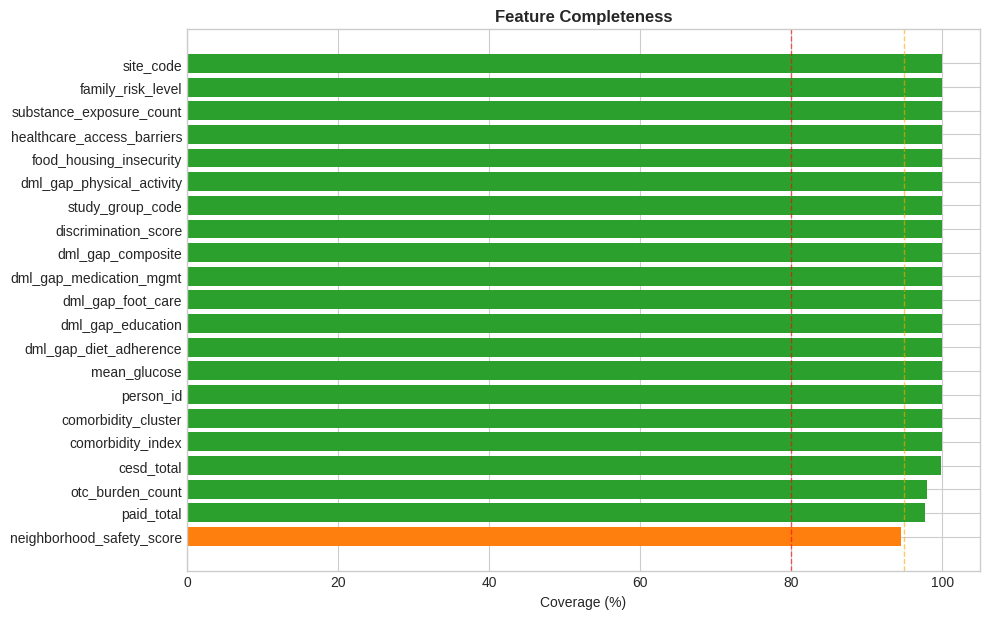

In [41]:
# ── 7a. Completeness audit ──────────────────────────────────────────

completeness = pd.DataFrame({
    'n_non_null':   features.notna().sum(),
    'coverage_pct': features.notna().mean() * 100,
}).sort_values('coverage_pct')

completeness['flag'] = completeness['coverage_pct'].apply(
    lambda x: 'LOW (<80%)' if x < 80 else ('MODERATE (80-95%)' if x < 95 else 'OK (>=95%)')
)

print('=== Feature Completeness Audit ===')
print(completeness.to_string())

fig, ax = plt.subplots(figsize=(10, max(6, len(completeness)*0.3)))
bar_c = completeness['coverage_pct'].apply(
    lambda x: '#d62728' if x < 80 else ('#ff7f0e' if x < 95 else '#2ca02c')
)
ax.barh(completeness.index, completeness['coverage_pct'], color=bar_c)
ax.axvline(80, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.axvline(95, color='orange', linestyle='--', alpha=0.6, linewidth=1)
ax.set_xlabel('Coverage (%)')
ax.set_title('Feature Completeness', fontweight='bold')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

=== Spearman correlations with Mean Glucose (ranked) ===
                              rho     p        n    sig
study_group_code            0.538 0.000 2245.000   True
paid_total                  0.221 0.000 2195.000   True
family_risk_level           0.169 0.000 2245.000   True
comorbidity_index           0.166 0.000 2245.000   True
dml_gap_physical_activity   0.162 0.000 2245.000   True
dml_gap_education          -0.160 0.000 2245.000   True
dml_gap_foot_care          -0.140 0.000 2245.000   True
substance_exposure_count   -0.120 0.000 2245.000   True
comorbidity_cluster        -0.110 0.000 2245.000   True
dml_gap_medication_mgmt    -0.066 0.002 2245.000   True
dml_gap_composite          -0.061 0.004 2245.000   True
discrimination_score        0.049 0.019 2245.000   True
dml_gap_diet_adherence      0.047 0.025 2245.000   True
site_code                  -0.044 0.037 2245.000   True
neighborhood_safety_score  -0.036 0.097 2121.000  False
healthcare_access_barriers  0.027 0.203 2245.00

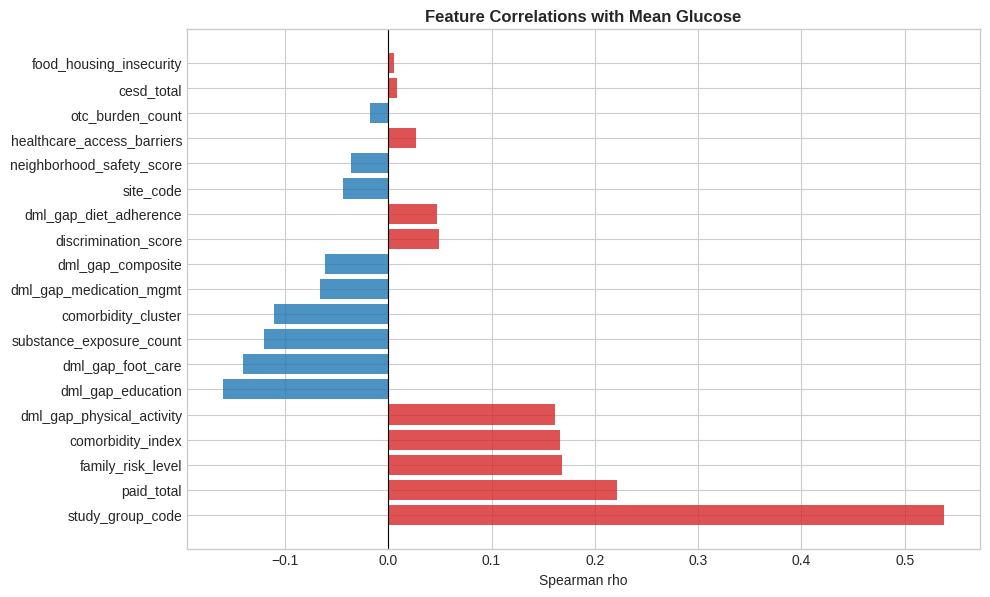

In [42]:
# ── 7b. Ranked Spearman correlations with mean glucose ────────────────────

numeric_cols    = features.select_dtypes(include='number').columns.tolist()
predictor_cols  = [c for c in numeric_cols if c not in ('mean_glucose', 'person_id')]

correlations = {}
for col in predictor_cols:
    sub = features[['mean_glucose', col]].dropna()
    if len(sub) > 30:
        rho, p = stats.spearmanr(sub['mean_glucose'], sub[col])
        correlations[col] = {'rho': rho, 'p': p, 'n': len(sub)}

corr_df = pd.DataFrame(correlations).T.sort_values('rho', key=abs, ascending=False)
corr_df['sig'] = corr_df['p'] < 0.05

print('=== Spearman correlations with Mean Glucose (ranked) ===')
print(corr_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, max(5, len(corr_df)*0.32)))
bar_colors = corr_df['rho'].apply(lambda x: '#d62728' if x > 0 else '#1f77b4')
ax.barh(corr_df.index, corr_df['rho'], color=bar_colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman rho')
ax.set_title('Feature Correlations with Mean Glucose', fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# ── 7c. Summary table: glucose by cluster x study group ───────────────────

summary = (
    cgm_merged
    .dropna(subset=['comorbidity_cluster', 'study_group_label'])
    .groupby(['study_group_label', 'comorbidity_cluster'])['mean_glucose']
    .agg(['mean','std','median','count'])
    .round(2)
)
summary.index = summary.index.set_levels(
    summary.index.levels[1].map(CLUSTER_MAP), level=1
)
summary.columns = ['Mean (mg/dL)', 'SD', 'Median', 'N']
print('=== Mean Glucose by Study Group x Comorbidity Cluster ===')
print(summary.to_string())

=== Mean Glucose by Study Group x Comorbidity Cluster ===
                                                Mean (mg/dL)     SD  Median    N
study_group_label comorbidity_cluster                                           
Healthy           Cardiometabolic                    117.670 14.180 115.400  220
                  Musculoskeletal-Inflammatory       118.130 17.140 115.800  541
Insulin           Cardiometabolic                    173.900 45.770 170.180  147
                  Musculoskeletal-Inflammatory       177.980 49.260 164.980  104
Oral Med          Cardiometabolic                    146.850 34.140 139.270  334
                  Musculoskeletal-Inflammatory       147.970 37.930 139.100  347
Pre-DM            Cardiometabolic                    125.430 22.020 122.140  218
                  Musculoskeletal-Inflammatory       126.140 22.610 122.810  334


In [44]:
# ── 7d. Multicollinearity flags ─────────────────────────────────────────

print('=== Multicollinearity Flags for Modeling ===')
flag_pairs = [
    ('comorbidity_cluster',      'comorbidity_index'),
    ('comorbidity_cluster',      'study_group_code'),
    ('comorbidity_index',        'study_group_code'),
    ('cesd_total',               'paid_total'),
    ('substance_exposure_count', 'otc_burden_count'),
]

for a, b in flag_pairs:
    if a in features.columns and b in features.columns:
        sub = features[[a, b]].dropna()
        rho, p = stats.spearmanr(sub[a], sub[b])
        flag = '*** HIGH ***' if abs(rho) > 0.7 else ('** MODERATE **' if abs(rho) > 0.4 else '')
        print(f'  {a:35s} vs {b:30s}: rho={rho:.3f}  {flag}')

print()
print('Modeling recommendations:')
print('  1. Run models BOTH with and without comorbidity_cluster')
print('  2. Tree-based models (XGBoost, RF) handle multicollinearity better than linear')
print('  3. Consider study_group_code as stratification rather than a feature')
print('  4. Interaction term: comorbidity_cluster x study_group_code may be informative')

=== Multicollinearity Flags for Modeling ===
  comorbidity_cluster                 vs comorbidity_index             : rho=-0.809  *** HIGH ***
  comorbidity_cluster                 vs study_group_code              : rho=-0.207  
  comorbidity_index                   vs study_group_code              : rho=0.273  
  cesd_total                          vs paid_total                    : rho=0.328  
  substance_exposure_count            vs otc_burden_count              : rho=0.058  

Modeling recommendations:
  1. Run models BOTH with and without comorbidity_cluster
  2. Tree-based models (XGBoost, RF) handle multicollinearity better than linear
  3. Consider study_group_code as stratification rather than a feature
  4. Interaction term: comorbidity_cluster x study_group_code may be informative


In [45]:
# ── 7e. Output file verification ────────────────────────────────────────

print('=== Notebook 07 Output Files ===')
for fname in ['comorbidity_clusters.csv', 'cgm_aggregated.csv',
              'features_with_cluster.csv', 'features_without_cluster.csv']:
    fpath = out_dir / fname
    if fpath.exists():
        df_check = pd.read_csv(fpath)
        print(f'  {fname}: {len(df_check):,} rows x {df_check.shape[1]} cols')
    else:
        print(f'  {fname}: NOT FOUND')

print()
print('=== Key Findings ===')
print(f'  CGM participants:      {len(cgm):,}')
print(f'  Cluster 0 (Cardiomet): {(cgm_merged["comorbidity_cluster"]==0).sum():,}')
print(f'  Cluster 1 (Musc-Inf):  {(cgm_merged["comorbidity_cluster"]==1).sum():,}')
print(f'  Features (w/ cluster): {with_cluster.shape[1]-2}')
print(f'  Features (w/o cluster):{without_cluster.shape[1]-2}')

=== Notebook 07 Output Files ===
  comorbidity_clusters.csv: 2,280 rows x 3 cols
  cgm_aggregated.csv: 2,245 rows x 9 cols
  features_with_cluster.csv: 2,245 rows x 21 cols
  features_without_cluster.csv: 2,245 rows x 20 cols

=== Key Findings ===
  CGM participants:      2,245
  Cluster 0 (Cardiomet): 919
  Cluster 1 (Musc-Inf):  1,326
  Features (w/ cluster): 19
  Features (w/o cluster):18


In [46]:
# ── Output files are already saved to Google Drive ──────────────────────────
# out_dir points directly to My Drive/ORGANIZATIONS/ucsftech_outputs/
# so all CSV exports above landed there automatically. No copy needed.
print('Output files are in:', out_dir)
for fname in ['comorbidity_clusters.csv', 'cgm_aggregated.csv',
              'features_with_cluster.csv', 'features_without_cluster.csv']:
    fpath = out_dir / fname
    status = f'{fpath.stat().st_size:,} bytes' if fpath.exists() else 'MISSING'
    print(f'  {fname}: {status}')


Output files are in: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs
  comorbidity_clusters.csv: 25,337 bytes
  cgm_aggregated.csv: 144,421 bytes
  features_with_cluster.csv: 285,091 bytes
  features_without_cluster.csv: 280,581 bytes
